In [23]:
import warnings
warnings.simplefilter('ignore') #ignore matplotlib complaints about multiple imports

import numpy as np
import pandas as pd
import timecorr as tc
import hypertools as hyp
import supereeg as se
from matplotlib import pyplot as plt
import seaborn as sns
import os
from glob import glob as lsdir
from scipy.io import loadmat as load
import numba

%matplotlib inline

In [3]:
datadir = os.path.join(os.getenv('HOME'), 'data', 'fMRI', 'dffr')
nii_files = lsdir(os.path.join(datadir, '*.nii'))
regressor_files = lsdir(os.path.join(datadir, 'regmats', '*.mat'))

In [4]:
x = se.Nifti(nii_files[0])

In [5]:
xBrain = se.Brain(x, filter=None)

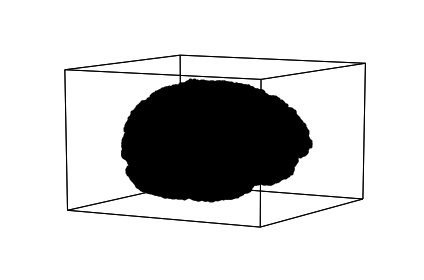

In [6]:
xBrain.plot_locs()

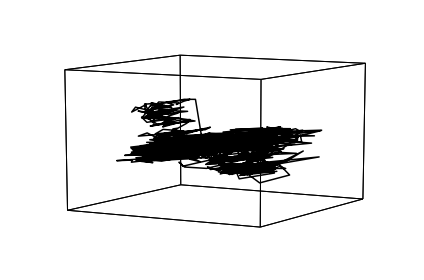

In [7]:
hyp.plot(xBrain.get_data(), 'k-')

In [8]:
miniBrain = xBrain.get_slice(loc_inds=np.arange(10))

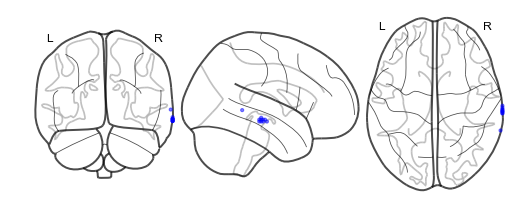

In [9]:
miniBrain.plot_locs()

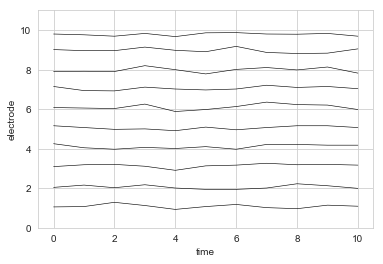

In [10]:
miniBrain.plot_data()

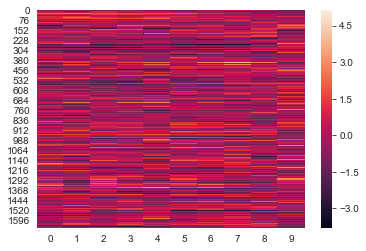

In [11]:
sns.heatmap(miniBrain.get_data())

In [12]:
mini_corrs = tc.timecorr(miniBrain.get_data())

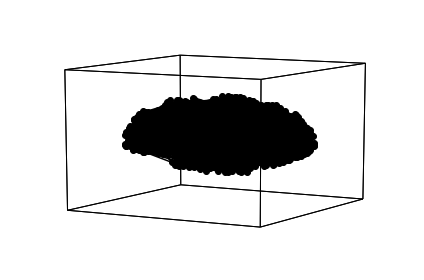

In [13]:
hyp.plot(miniBrain.get_data(), 'ko-', reduce='UMAP')

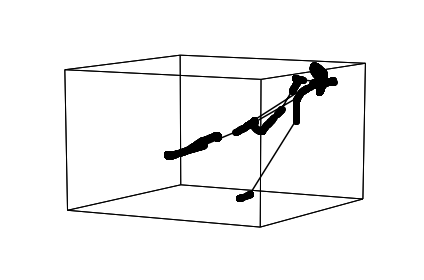

In [14]:
hyp.plot(mini_corrs, 'ko-', reduce='UMAP')

In [16]:
r0 = load(regressor_files[0])

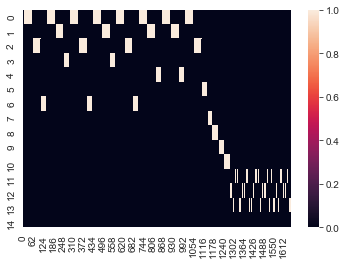

In [19]:
sns.heatmap(r0['all_regressors'])

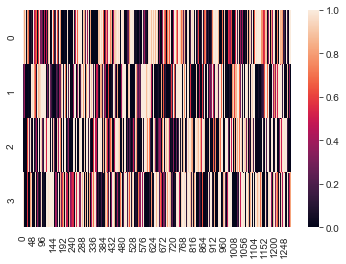

In [21]:
sns.heatmap(r0['results'])

In [25]:
# credit: https://stackoverflow.com/questions/47004506/check-if-a-numpy-array-is-sorted
@numba.jit
def is_sorted(a):
    for i in range(a.size-1):
         if a[i+1] < a[i] :
               return False
    return True

In [31]:
def ribbon(x, y, lb, ub=None, color='k', alpha='0.5'):
    #assert is_sorted(x), 'x-coordinates must be monotonically increasing'
    
    if ub is None:
        ub = lb
    h1 = plt.fill_between(x, y-lb, y+ub, color=color, alpha=alpha)
    h2 = plt.plot(x, y, color=color)
    return h1, h2

TypeError: '<' not supported between instances of 'str' and 'int'

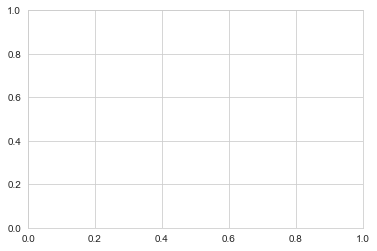

In [32]:
ribbon(np.arange(10), np.random.rand(10), np.random.randn(10))